In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import configuration
from Datasets.config.titanic_config import (
    DATASET_PATH, TARGET_COLUMN, TEST_SIZE, RANDOM_STATE,
    NUMERIC_COLS, CATEGORICAL_COLS, DROP_COLS
)

# Import reusable functions
from src.preprocess import load_dataset, explore_data, handle_missing_numeric, handle_missing_categorical, encode_categorical
from src.utils import print_section, print_subsection, plot_confusion_matrix, print_dataset_summary

## Load Data

In [ ]:
print_section("Loading Titanic Training Dataset")
data_train = load_dataset(DATASET_PATH)
print(f"Training data shape: {data_train.shape}")
data_train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
print_section("Loading Titanic Test Dataset")
# Test data is in the same directory as train data
test_path = DATASET_PATH.replace('train.csv', 'test.csv')
data_test = load_dataset(test_path)
print(f"Test data shape: {data_test.shape}")
data_test.head(10)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
5,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,NaN,S
6,898,3,"Connolly, Miss. Kate",female,30.0,0,0,330972,7.6292,NaN,Q
7,899,2,"Caldwell, Mr. Albert Francis",male,26.0,1,1,248738,29.0000,NaN,S
8,900,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.0,0,0,2657,7.2292,NaN,C
9,901,3,"Davies, Mr. John Samuel",male,21.0,2,0,A/4 48871,24.1500,NaN,S


In [4]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## Handling missing values

<p>As I see in info() that total number of rows is 891 but Age data available is 714 and Cabin 204 and Embarked 889 .I can drop Cabin column as it is not an important feature and also it has a lot of missing values .For other columns I can fill them with other values appropriate</p>

In [5]:
data_train=data_train.drop(columns=["Cabin"])

In [6]:
mean_age = np.round(data_train["Age"].mean(),2)
mean_age

np.float64(29.7)

In [7]:
data_train["Age"]=data_train["Age"].fillna(mean_age)

In [8]:
mode_val = data_train["Embarked"].mode()[0]
mode_val

'S'

In [9]:
data_train["Embarked"]=data_train["Embarked"].fillna(mode_val)

In [10]:
data_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


Feature Scaling and Label Encoding

In [11]:
numerical_features= data_train.select_dtypes(include=['number']).columns.tolist()


In [12]:
data_train=data_train.drop(columns=['Name', 'Ticket','PassengerId'])


In [13]:
categorical_features = data_train.select_dtypes(include=['str']).columns.tolist()

In [14]:
categorical_features

['Sex', 'Embarked']

In [15]:
data_train['Sex']=data_train['Sex'].map({'male':1,'female':2})
data_train['Embarked'] = data_train['Embarked'].map({'Q':1,'S':2,'C':3})

In [16]:
data_train['Embarked']

0      2
1      3
2      2
3      2
4      2
      ..
886    2
887    2
888    2
889    3
890    1
Name: Embarked, Length: 891, dtype: int64

In [17]:
corr  = data_train.corr()

<Axes: >

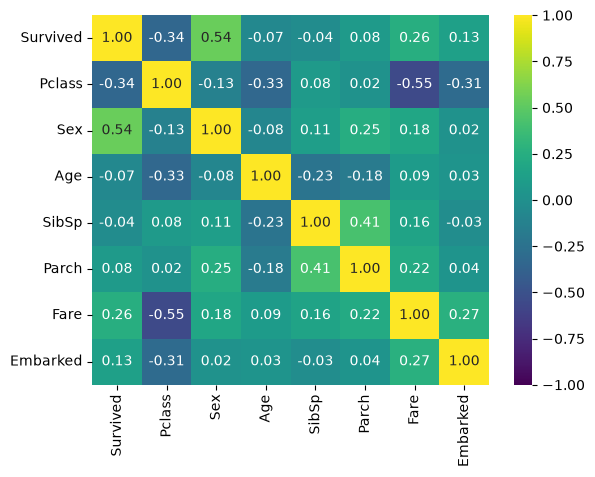

In [18]:
import seaborn as sns

sns.heatmap(corr,annot=True,fmt='.2f',cmap='viridis',vmin=-1,vmax=1)

In [19]:
data_train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [27]:
data_train['Sex'].value_counts()

Sex
1    577
2    314
Name: count, dtype: int64

## Univariate Analysis

<Axes: xlabel='Sex', ylabel='Count'>

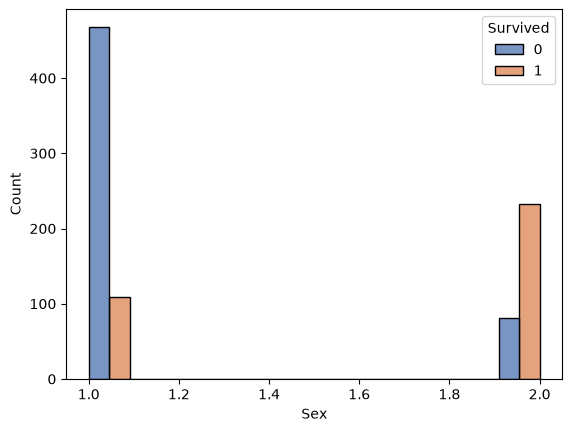

In [26]:
sns.histplot(x=data_train['Sex'],hue = data_train['Survived'],multiple="dodge",palette='deep')

# female Survival Rate is more than male

In [40]:
labels = ['0-10','10-18','18-27','27-40','40-60','60-80']
bins=6
data_train['age_range'] = pd.cut(data_train['Age'],labels=labels,bins=bins,right=True)

In [41]:
data_train.Age.value_counts()

Age
29.70    177
24.00     30
22.00     27
18.00     26
28.00     25
        ... 
24.50      1
0.67       1
0.42       1
34.50      1
74.00      1
Name: count, Length: 89, dtype: int64

<Axes: xlabel='Age'>

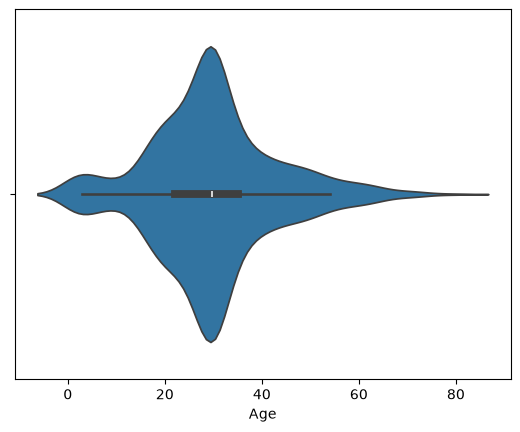

In [42]:
sns.violinplot(x=data_train['Age'])

<Axes: xlabel='Age'>

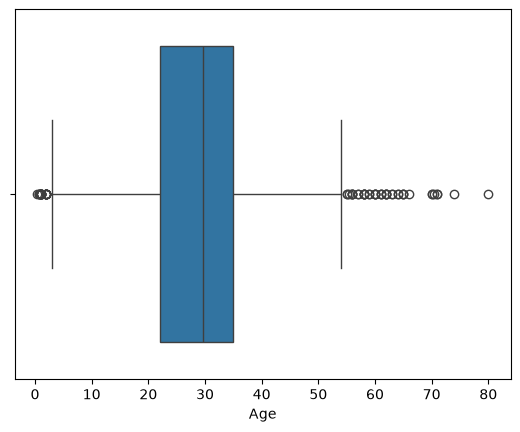

In [43]:
sns.boxplot(x=data_train['Age'])

<Axes: xlabel='age_range', ylabel='Count'>

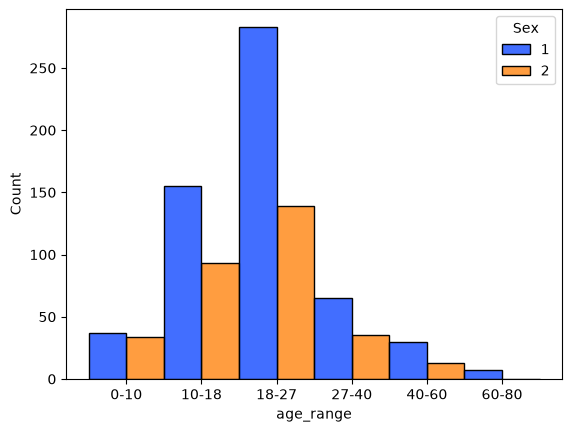

In [44]:
sns.histplot(x=data_train['age_range'],hue=data_train['Sex'],multiple='dodge',palette='bright')

<Axes: xlabel='age_range', ylabel='Count'>

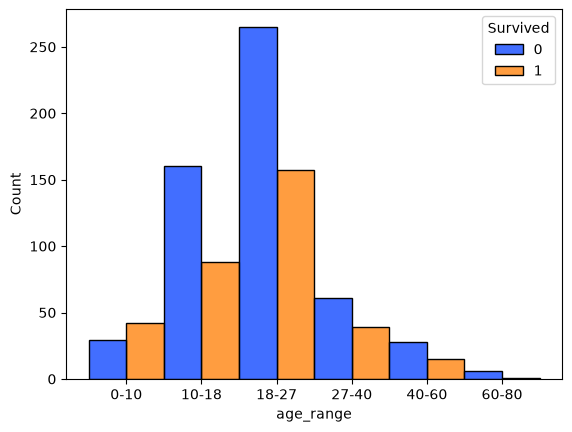

In [45]:
sns.histplot(x=data_train['age_range'],hue=data_train['Survived'],multiple='dodge',palette='bright')

In [46]:
data_train_male=data_train[data_train['Sex']==1]
data_train_female=data_train[data_train['Sex']==2]

<Axes: xlabel='age_range', ylabel='Count'>

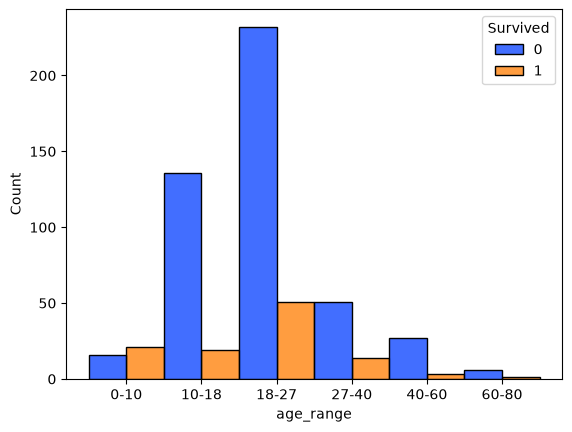

In [48]:
sns.histplot(x=data_train_male['age_range'],hue=data_train_male['Survived'],multiple='dodge',palette='bright')

<Axes: xlabel='age_range', ylabel='Count'>

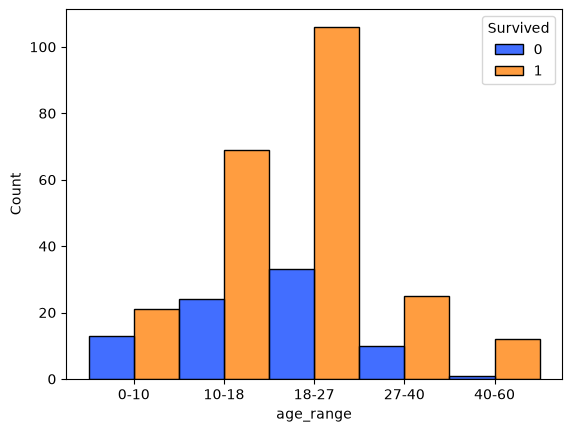

In [49]:
sns.histplot(x=data_train_female['age_range'],hue=data_train_female['Survived'],multiple='dodge',palette='bright')

# Female and  children -->(below or equal 10) survived more than others 

In [50]:
data_train = data_train.drop(columns=['Fare'])

In [53]:
data_train['family_size']=data_train['Parch']+data_train['SibSp']+1

In [54]:
data_train = data_train.drop(columns=['Parch','SibSp'])

In [55]:
data_train.head()


,Survived,Pclass,Sex,Age,Embarked,age_range,family_size
0,0,3,1,22.0,2,10-18,2
1,1,1,2,38.0,3,18-27,2
2,1,3,2,26.0,2,10-18,1
3,1,1,2,35.0,2,18-27,2
4,0,3,1,35.0,2,18-27,1


In [56]:
data_train_alone = data_train[data_train['family_size']==1]

<Axes: xlabel='Survived', ylabel='Count'>

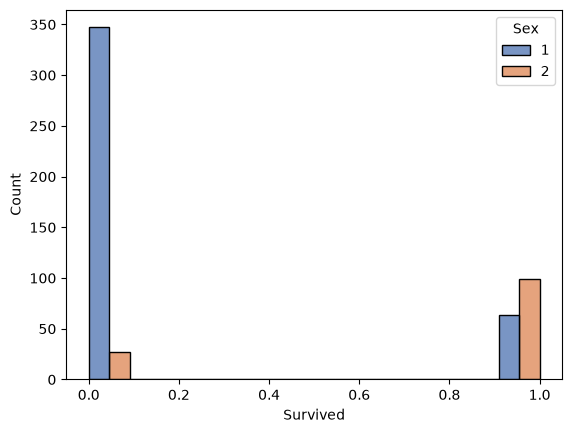

In [58]:
sns.histplot(data= data_train_alone,x=data_train_alone['Survived'],hue=data_train_alone['Sex'],multiple='dodge',palette='deep')

In [60]:
data_train_not_alone = data_train[data_train['family_size']!=1]

<Axes: xlabel='Survived', ylabel='Count'>

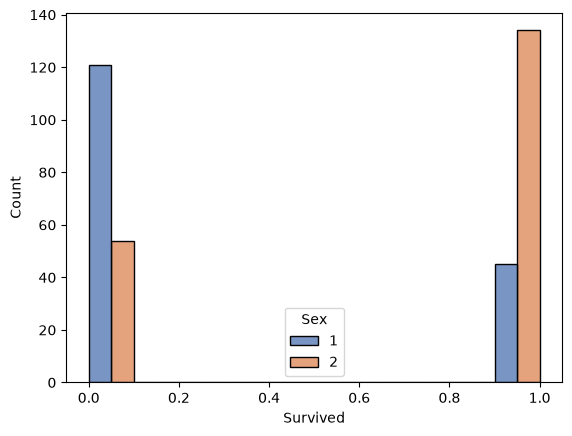

In [61]:
sns.histplot(data= data_train_not_alone,x=data_train_not_alone['Survived'],hue=data_train_not_alone['Sex'],multiple='dodge',palette='deep')

## Those who were alone survived lesser than who were not alone . 
## **Advise**: <font color='blue'> Always travel with family</font>

<Axes: xlabel='Pclass', ylabel='Count'>

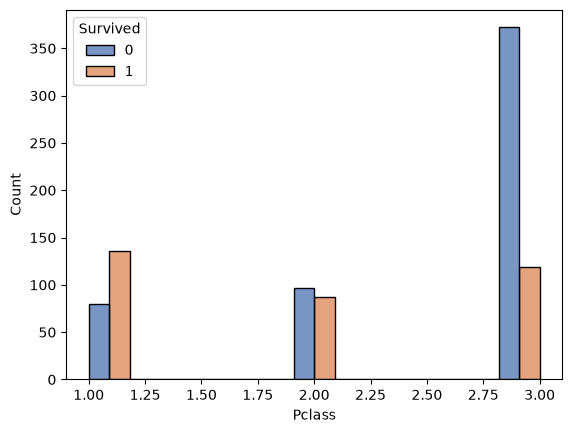

In [64]:
sns.histplot(x=data_train['Pclass'],hue=data_train['Survived'],multiple='dodge',palette='deep')

## Social Class was a  crucial factor in Survival  